In [55]:
!pip uninstall -y kaleido
!pip install kaleido==0.2.1

Found existing installation: kaleido 1.3.0
Uninstalling kaleido-1.3.0:
  Successfully uninstalled kaleido-1.3.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 10.8 MB/s eta 0:00:00


In [1]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import plotly.express as px
import plotly.graph_objects as go
from matplotlib.ticker import MaxNLocator
from IPython.display import Image, display

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
data = pd.read_excel('/content/drive/MyDrive/Maestria/Semestre 3/Seminario II/Review/Nuevo/Final_ma.xlsx')
data.columns

Index(['Unnamed: 0', 'Authors', 'Author full names', 'Author(s) ID', 'Title',
       'Year', 'Source title', 'Volume', 'Issue', 'Art. No.', 'Page start',
       'Page end', 'Page count', 'Cited by', 'DOI', 'Link', 'Affiliations',
       'Authors with affiliations', 'Abstract', 'Author keywords',
       'Index Keywords', 'Molecular Sequence Numbers', 'Chemicals/CAS',
       'Tradenames', 'Manufacturers', 'Funding Details', 'Funding Texts',
       'References', 'Correspondence Address', 'Editors', 'Publisher',
       'Sponsors', 'Conference name', 'Conference date', 'Conference location',
       'Conference code', 'ISSN', 'ISBN', 'CODEN', 'PubMed ID',
       'Language of Original Document', 'Abbreviated Source Title',
       'Document Type', 'Publication Stage', 'Open Access', 'Source', 'EID',
       'Country', 'Group', 'Model', 'Other variables', 'temp_range',
       'temp_value', 'humidity', 'rainfall', 'wind_speed', 'accuracy', 'r2',
       'rmse', 'standard_error', 'Disease', 'Coment

In [4]:
unique_diseases = data['Disease'].dropna().unique()
palette = sns.color_palette('pastel', n_colors=len(unique_diseases))
disease_colors = dict(zip(unique_diseases, palette))

In [5]:
def format_pathogen_name(name):
    name = str(name).strip()

    if 'leaf roll virus' in name.lower() or 'leafroll virus' in name.lower():
        return 'Potato leafroll virus'

    if name.startswith('Candidatus'):
        rest = name.replace('Candidatus', '', 1).strip()
        return r'$\mathit{Candidatus}$ ' + rest

    if ' subsp. ' in name:
        genus_species, epithet = name.split(' subsp. ')
        gs = genus_species.strip().replace(' ', r'\ ')
        ep = epithet.strip().replace(' ', r'\ ')
        return rf'$\mathit{{{gs}}}$ subsp. $\mathit{{{ep}}}$'

    words = name.replace(' ', r'\ ')
    return rf'$\mathit{{{words}}}$'

for d in unique_diseases:
    print(d, '->', format_pathogen_name(d))

Phytophthora infestans -> $\mathit{Phytophthora\ infestans}$
Alternaria solani -> $\mathit{Alternaria\ solani}$
Potato leaf roll virus -> Potato leafroll virus
Pectobacterium atrocepticum -> $\mathit{Pectobacterium\ atrocepticum}$
Candidatus Liberibacter solanacearum -> $\mathit{Candidatus}$ Liberibacter solanacearum
Ralstonia solanacearum -> $\mathit{Ralstonia\ solanacearum}$
Pectobacterium atrosepticum -> $\mathit{Pectobacterium\ atrosepticum}$
Pectobacterium carotovorum subsp. brasiliense -> $\mathit{Pectobacterium\ carotovorum}$ subsp. $\mathit{brasiliense}$
Pectobacterium parmentieri -> $\mathit{Pectobacterium\ parmentieri}$
Dickeya solani -> $\mathit{Dickeya\ solani}$


In [6]:
_num_re = re.compile(r"[-+]?\d*\.?\d+")

def _clean_bracket(s):
    return s.strip("[]").replace("'", "").replace('"', "").strip()

def parse_climate_ranges(raw):
    if pd.isna(raw):
        return []
    s = str(raw).strip()
    if s in ('', '[]', 'nan', 'None'):
        return []

    chunks = [c for c in re.split(r"\]\s*,\s*\[|;", s) if c.strip()]
    if len(chunks) == 1:
        chunks = [s]

    out = []
    for chunk in chunks:
        c = _clean_bracket(chunk)
        if not c:
            continue
        parts = [p.strip() for p in c.split(',') if p.strip() != '']
        if len(parts) == 1:
            val = parts[0]
            arrow = None
            if val.startswith('>'):
                arrow = 'right'
                val = val[1:]
            elif val.startswith('<'):
                arrow = 'left'
                val = val[1:]
            m = _num_re.search(val)
            if m:
                v = float(m.group())
                out.append((v, v, arrow))
        elif len(parts) >= 2:
            m0 = _num_re.search(parts[0])
            m1 = _num_re.search(parts[1])
            if m0 and m1:
                out.append((float(m0.group()), float(m1.group()), None))
    return out


def extraer_numeros(valor):
    if pd.isna(valor):
        return []
    if isinstance(valor, (list, tuple)):
        numeros = []
        for item in valor:
            if isinstance(item, str):
                numeros.extend(float(n) for n in _num_re.findall(item))
            elif isinstance(item, (int, float)):
                numeros.append(float(item))
        return numeros
    if isinstance(valor, str):
        return [float(n) for n in _num_re.findall(valor)]
    if isinstance(valor, (int, float)):
        return [float(valor)]
    return []


In [7]:
GROUP_STYLE = {
    'Deterministic':            dict(marker='o', label='Deterministic'),
    'Based on probability':     dict(marker='s', label='Based on probability'),
    'Artificial Intelligence':  dict(marker='D', label='Artificial intelligence'),
}

DISEASE_ORDER = [
    'Ralstonia solanacearum',
    'Potato leaf roll virus',
    'Phytophthora infestans',
    'Pectobacterium parmentieri',
    'Pectobacterium carotovorum subsp. brasiliense',
    'Pectobacterium atrosepticum',
    'Pectobacterium atrocepticum',
    'Dickeya solani',
    'Candidatus Liberibacter solanacearum',
    'Alternaria solani',
]
def build_forest_plot(data, range_col, point_col, var_label, unit,
                       disease_colors, fix_small_scale=False, jitter=0.16,
                       disease_order=DISEASE_ORDER):
    df = data.copy()
    df['_ranges'] = df[range_col].apply(parse_climate_ranges)
    if point_col is not None and point_col in df.columns:
        df['_points'] = df[point_col].apply(parse_climate_ranges)
    else:
        df['_points'] = [[] for _ in range(len(df))]

    records = []
    for _, row in df.iterrows():
        disease = row['Disease']
        group = row['Group']
        for (rmin, rmax, arrow) in row['_ranges']:
            if fix_small_scale:
                if rmin is not None and rmin < 10:
                    rmin *= 3
                if rmax is not None and rmax < 10:
                    rmax *= 3
            records.append(dict(Disease=disease, Group=group, rmin=rmin, rmax=rmax,
                                 arrow=arrow, kind='range'))
        for (pmin, pmax, arrow) in row['_points']:
            records.append(dict(Disease=disease, Group=group, rmin=pmin, rmax=pmax,
                                 arrow=arrow, kind='point'))

    plot_df = pd.DataFrame(records, columns=['Disease', 'Group', 'rmin', 'rmax', 'arrow', 'kind'])
    if plot_df.empty:
        print(f'[{var_label}] No data to plot.')
        return None

    all_diseases = df['Disease'].dropna().unique()
    extra = [d for d in all_diseases if d not in disease_order]
    diseases_sorted = list(disease_order) + sorted(extra)
    y_base = {d: i for i, d in enumerate(diseases_sorted)}

    has_range = df[range_col].notna() if range_col in df.columns else pd.Series(False, index=df.index)
    has_point = df[point_col].notna() if (point_col and point_col in df.columns) else pd.Series(False, index=df.index)
    n_studies_total = int((has_range | has_point).sum())

    fig_h = max(3.5, 0.9 * len(diseases_sorted) + 1.5)
    fig, ax = plt.subplots(figsize=(16, fig_h))

    group_order = list(GROUP_STYLE.keys())
    offsets = {g: (i - (len(group_order) - 1) / 2) * jitter for i, g in enumerate(group_order)}
    n_by_disease = plot_df.groupby('Disease').size()

    for _, r in plot_df.iterrows():
        if r['Disease'] not in y_base:
            continue
        y = y_base[r['Disease']] + offsets.get(r['Group'], 0)
        color = disease_colors.get(r['Disease'], 'gray')
        marker = GROUP_STYLE.get(r['Group'], dict(marker='o'))['marker']

        if r['kind'] == 'range' and pd.notnull(r['rmin']) and pd.notnull(r['rmax']) and r['rmin'] != r['rmax']:
            ax.plot([r['rmin'], r['rmax']], [y, y], color=color, lw=3, solid_capstyle='round', zorder=2, alpha=0.85)
            ax.plot([r['rmin'], r['rmax']], [y, y], color='black', lw=0.6, zorder=3, alpha=0.6)
            ax.scatter([r['rmin'], r['rmax']], [y, y], marker=marker, s=45, color=color,
                       edgecolor='black', linewidth=0.6, zorder=4)
        elif pd.notnull(r['rmin']):
            if r['arrow'] == 'right':
                ax.annotate('', xy=(r['rmin'] + 1.5, y), xytext=(r['rmin'], y),
                            arrowprops=dict(facecolor=color, edgecolor='black', width=3, headwidth=8, lw=0.5))
            elif r['arrow'] == 'left':
                ax.annotate('', xy=(r['rmin'] - 1.5, y), xytext=(r['rmin'], y),
                            arrowprops=dict(facecolor=color, edgecolor='black', width=3, headwidth=8, lw=0.5))
            else:
                ax.scatter([r['rmin']], [y], marker=marker, s=55, color=color,
                           edgecolor='black', linewidth=0.6, zorder=4)

    ax.set_yticks(list(y_base.values()))
    ax.set_yticklabels([format_pathogen_name(d) for d in diseases_sorted], fontsize=13)
    ax.set_xlabel(f'{var_label} ({unit})', fontsize=14)
    ax.tick_params(axis='x', labelsize=12)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=10, prune=None))
    ax.grid(axis='x', linestyle='--', alpha=0.4)

    x0, x1 = ax.get_xlim()
    pad = (x1 - x0) * 0.02
    for d, y in y_base.items():
        n = n_by_disease.get(d, 0)
        ax.text(x1 + pad, y, f'n={n}', va='center', ha='left', fontsize=11, color='dimgray')
    ax.set_xlim(x0, x1 + (x1 - x0) * 0.2)

    legend_elems = [Line2D([0], [0], marker=s['marker'], color='gray', linestyle='',
                            markeredgecolor='black', markersize=9, label=s['label'])
                    for s in GROUP_STYLE.values()]
    ax.legend(handles=legend_elems, title='Model type', loc='upper left',
              bbox_to_anchor=(1.13, 1), fontsize=11, title_fontsize=12, frameon=True)

    plt.tight_layout()
    return fig

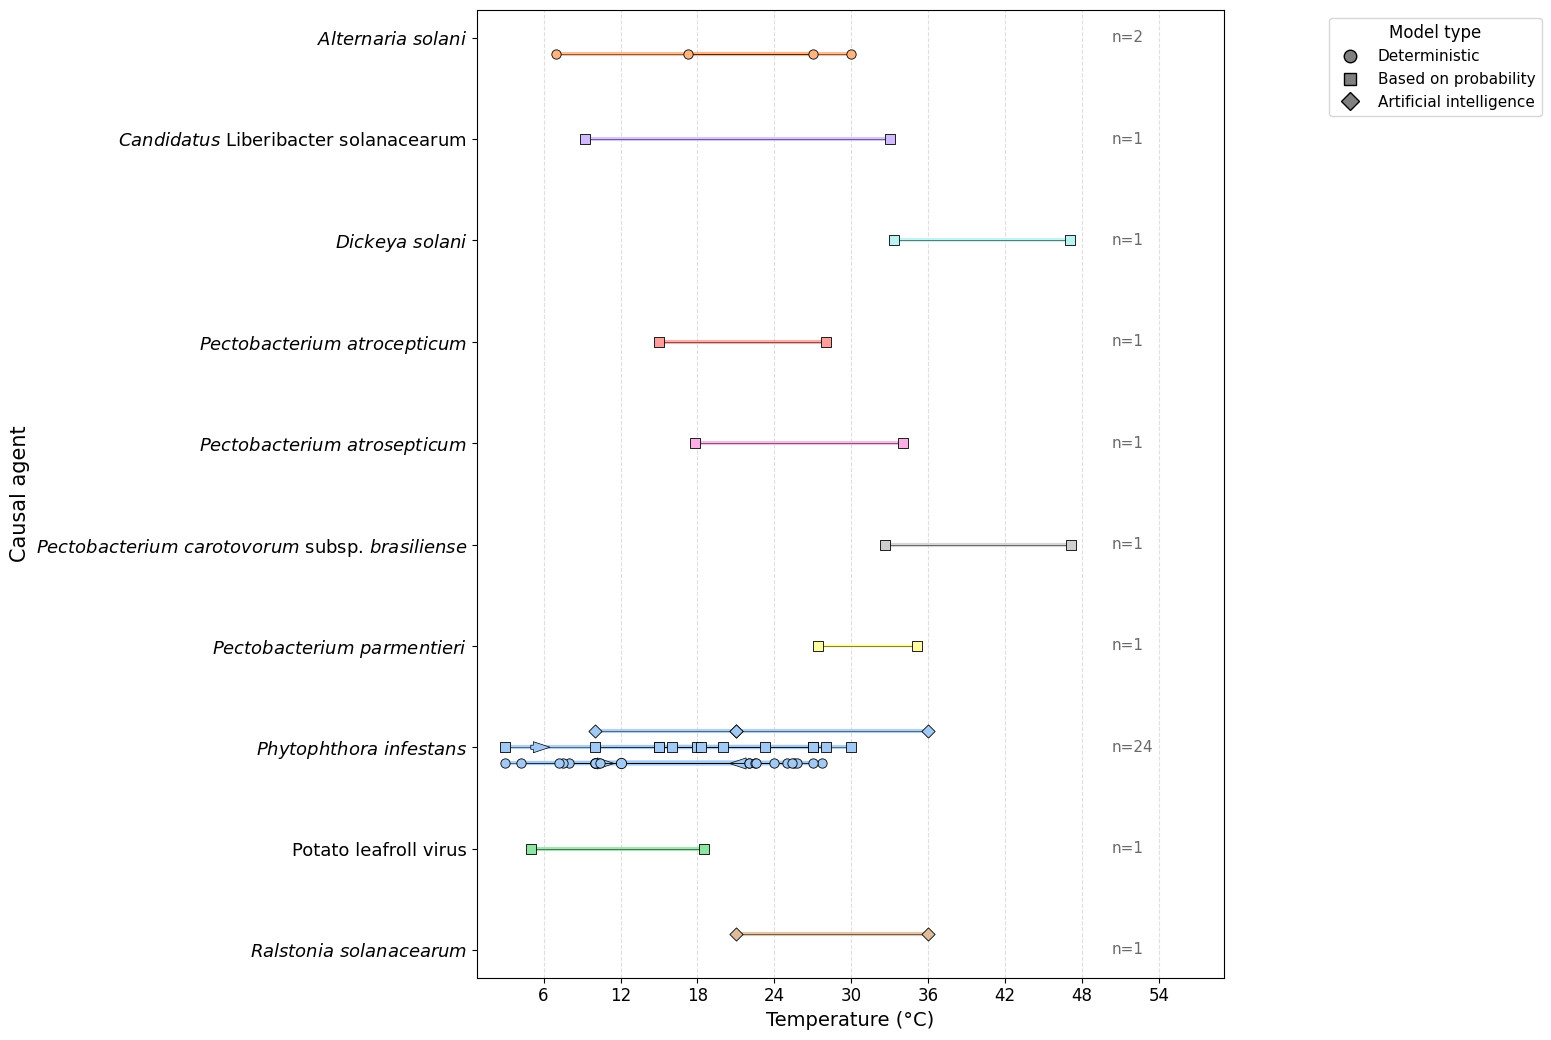

In [8]:
fig = build_forest_plot(data, 'temp_range', 'temp_value', 'Temperatura', '°C', disease_colors)
plt.xlabel('Temperature (°C)')
plt.ylabel('Causal agent',fontsize=15)
plt.show()

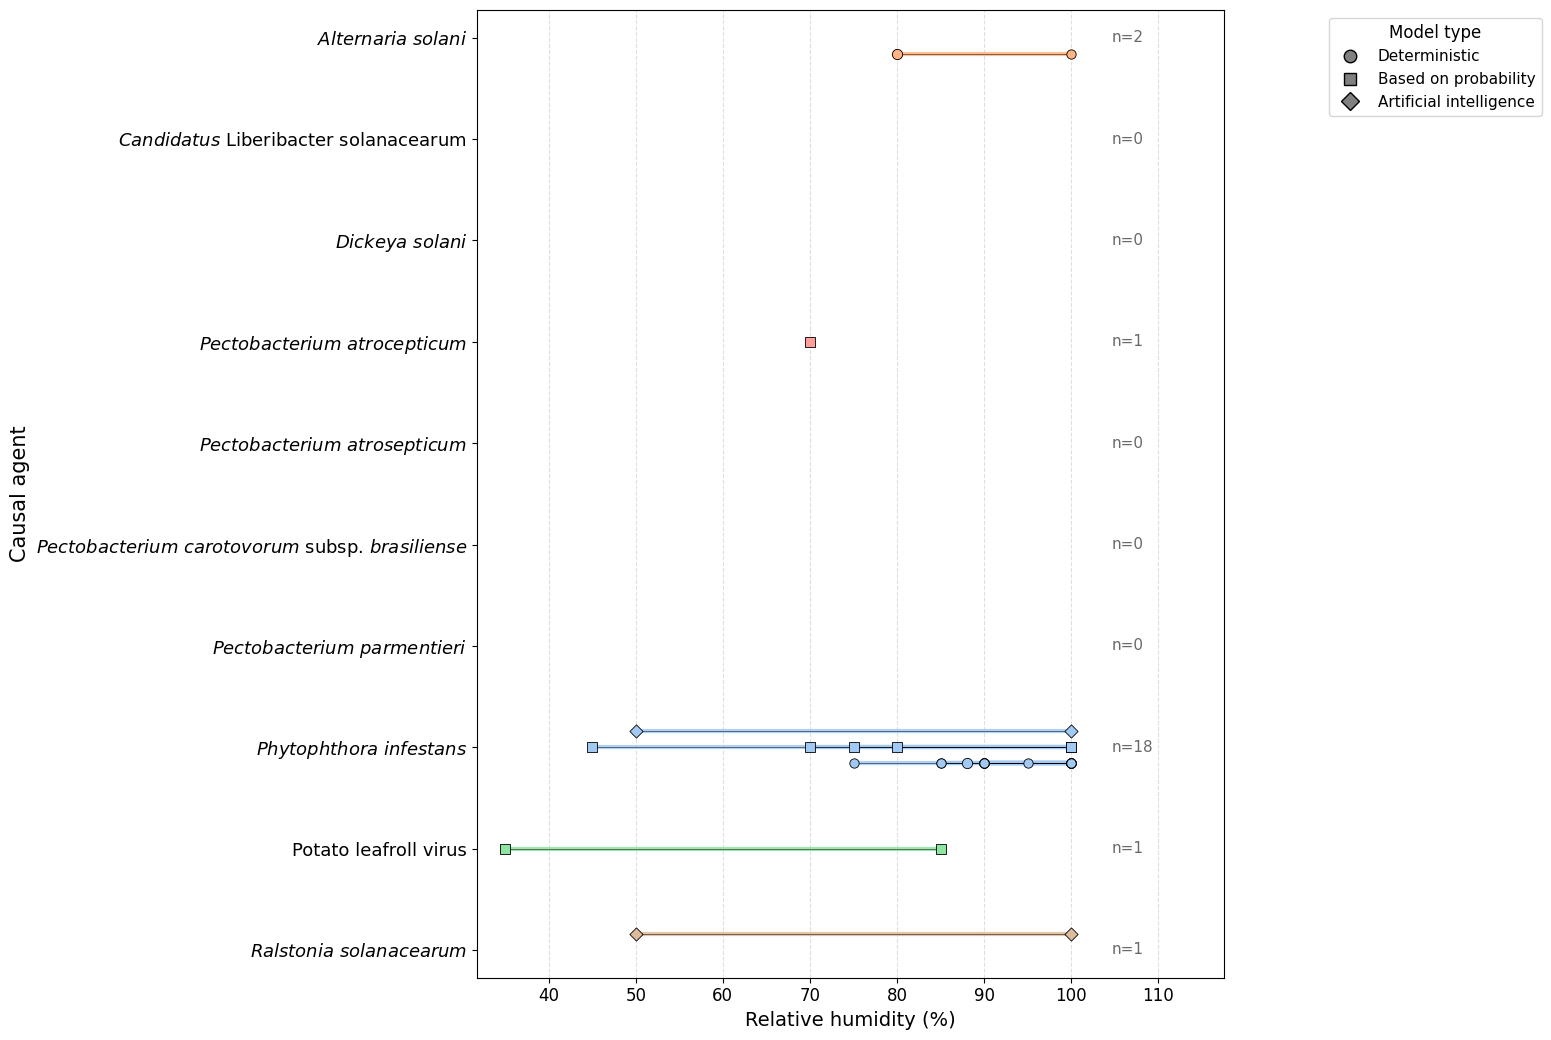

In [9]:
fig = build_forest_plot(data, 'humidity', None, 'Relative humidity', '%', disease_colors)
plt.ylabel('Causal agent',fontsize=15)
plt.show()

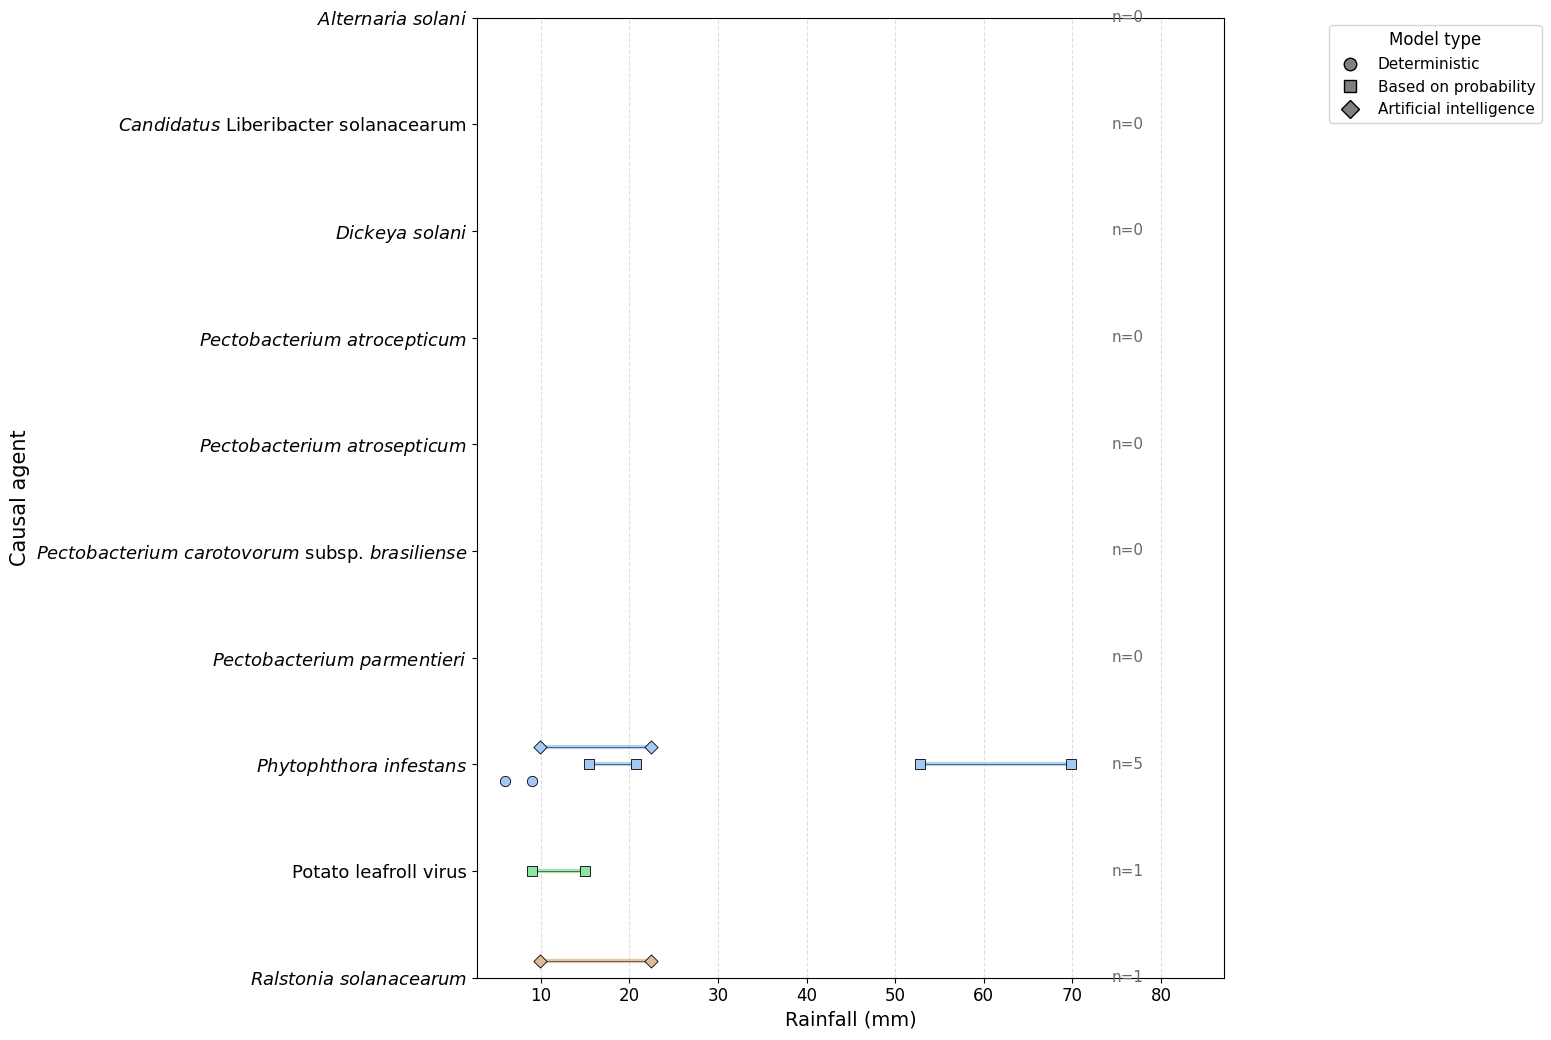

In [10]:
fig = build_forest_plot(data, 'rainfall', None, 'Rainfall', 'mm', disease_colors, fix_small_scale=True)
plt.ylabel('Causal agent',fontsize=15)
plt.show()

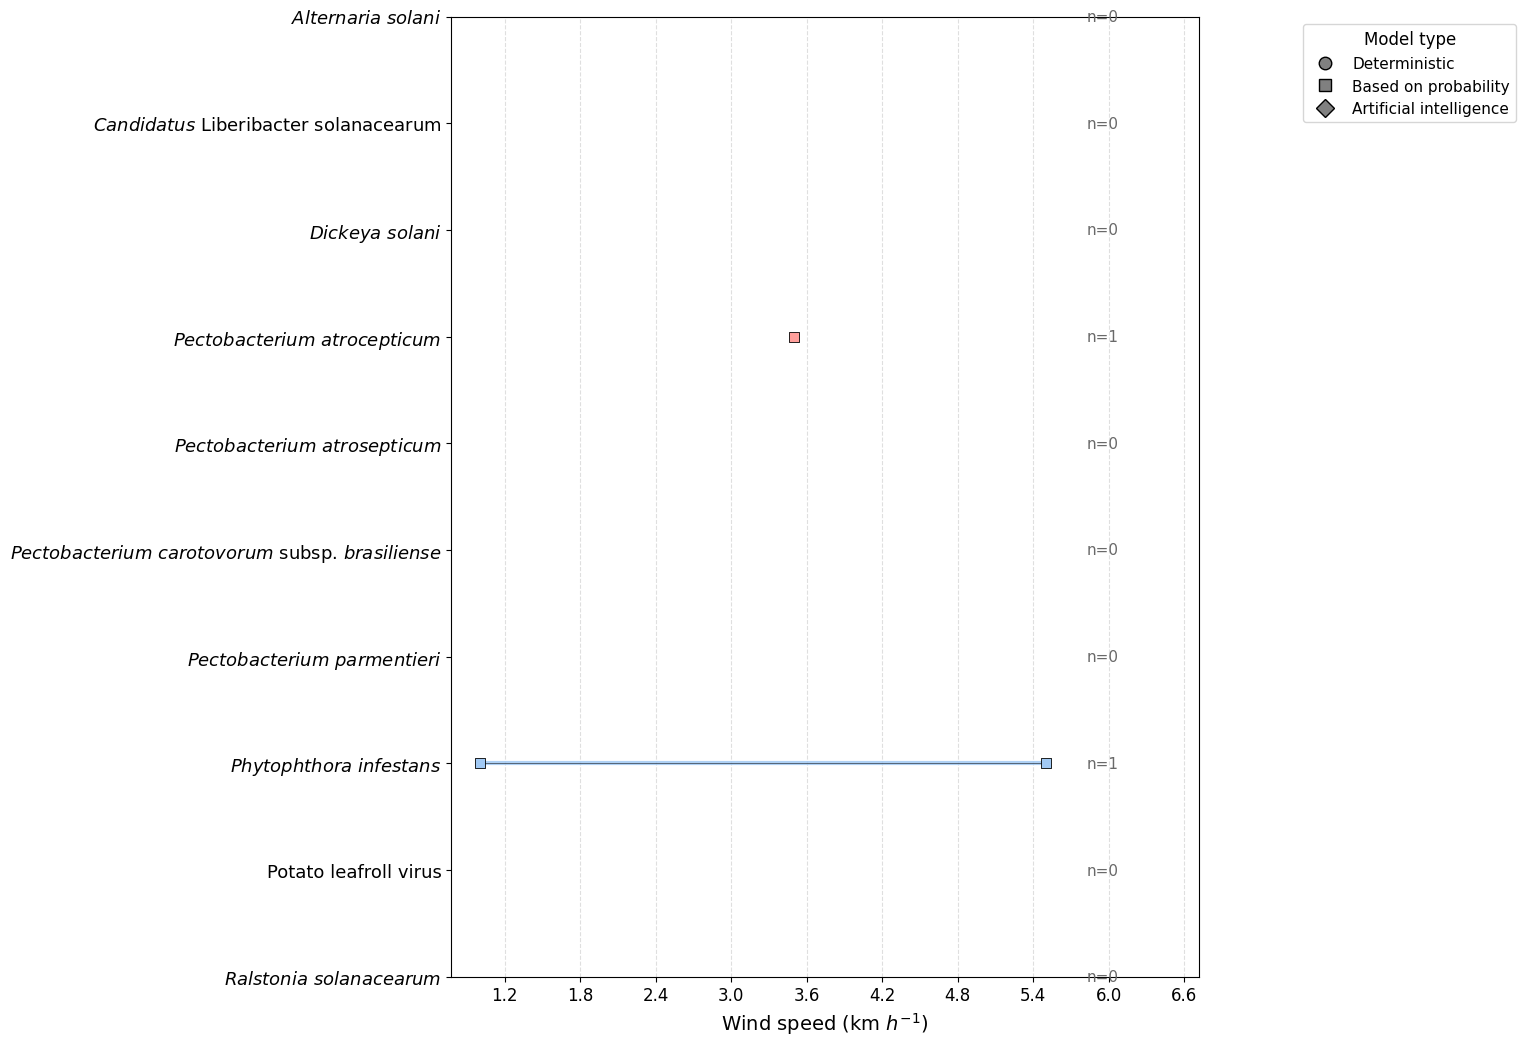

In [11]:
fig = build_forest_plot(data, 'wind_speed', None, 'Wind speed', 'km/h', disease_colors)
plt.xlabel('Wind speed (km $h^{-1}$)')
plt.show()

In [26]:
corrections = {
    r'\bMechanisistic\b': 'Mechanistic',
    r'\bfuntions?\b': 'functions',
    r'ofdisfavourable': 'of disfavourable',
    r'propitiousdays': 'propitious days',
    r'^odel of': 'Model of',
    r'simblight1\)': '(SIMBLIGHT1)',
    r'Mechanisistic model \(Blightsim$': 'Mechanistic model (Blightsim and Prophy)',
    r'relative humiditymodel of interrupted wet periods (IWP)':'Relative humidity model of interrupted wet periods (IWP)',
    r'the model of accumulation of disfavourable days (DD)':'Model of accumulation of disfavourable days (DD)'
}

def clean_model_text(text):
    text = str(text)
    for pattern, repl in corrections.items():
        text = re.sub(pattern, repl, text, flags=re.IGNORECASE)
    return text.strip()


def plot_model_frequency(df, group_name):
    terms = []
    for entry in df['Model'].dropna():
        entry_clean = clean_model_text(entry)
        split_terms = [t.strip() for t in entry_clean.split(';')]
        terms.extend([t for t in split_terms if t])

    counts = pd.Series(terms).value_counts().sort_values(ascending=True)
    total = counts.sum()
    pct = (counts / total * 100).round(1)

    fig = px.bar(
        x=counts.values,
        y=counts.index,
        orientation='h',
        color=counts.values,
        color_continuous_scale='Blues',
        labels={'x': 'Number of studies', 'y': ''},
        title=f'{group_name} (n = {int(total)} mentions)',
        text=[f'{c} ({p}%)' for c, p in zip(counts.values, pct.values)],
        template="plotly_white"
    )

    fig.update_traces(
        textposition='outside',
        cliponaxis=False,
    )

    fig.update_layout(
        coloraxis_showscale=False,
        font=dict(size=14, color='black'),
        title_font=dict(size=17),
        paper_bgcolor='white',
        plot_bgcolor='white',
        margin=dict(l=10, r=80, t=60, b=10),
        height=max(350, 28 * len(counts) + 120),
        xaxis=dict(
            range=[0, counts.values.max() * 1.35]
        ),
        yaxis=dict(
            automargin=True,
        ),
    )

    return fig

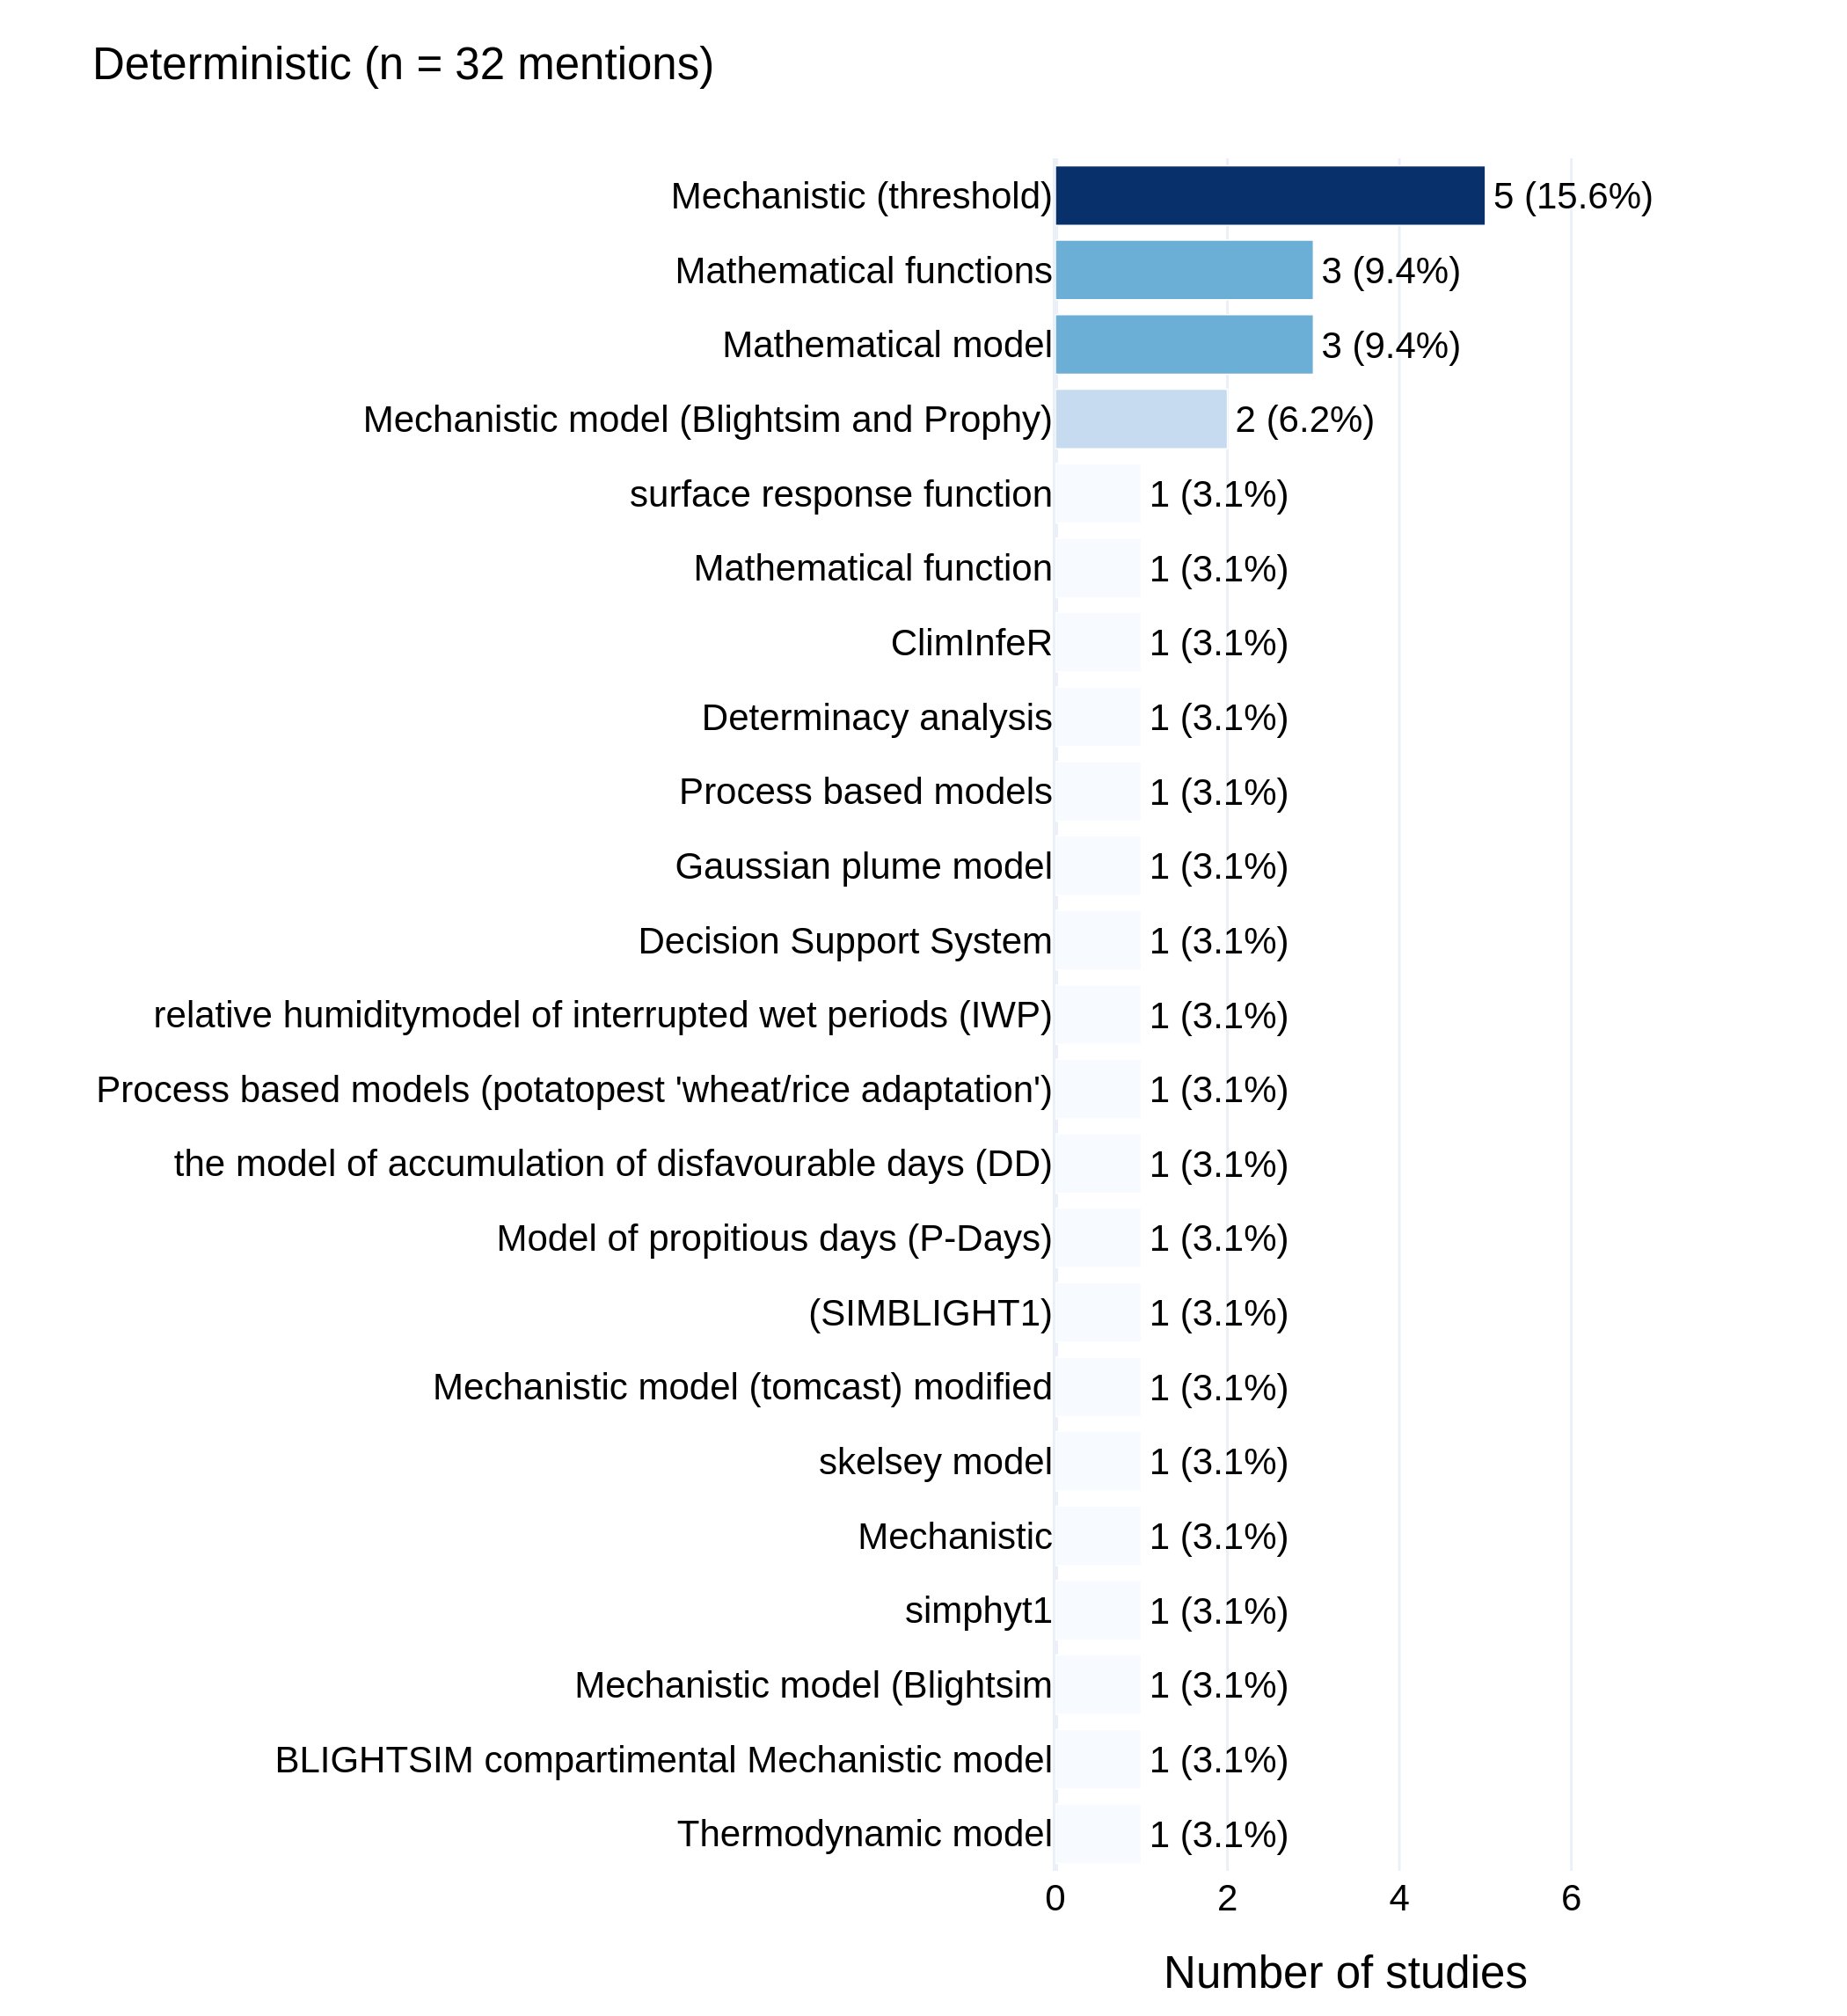

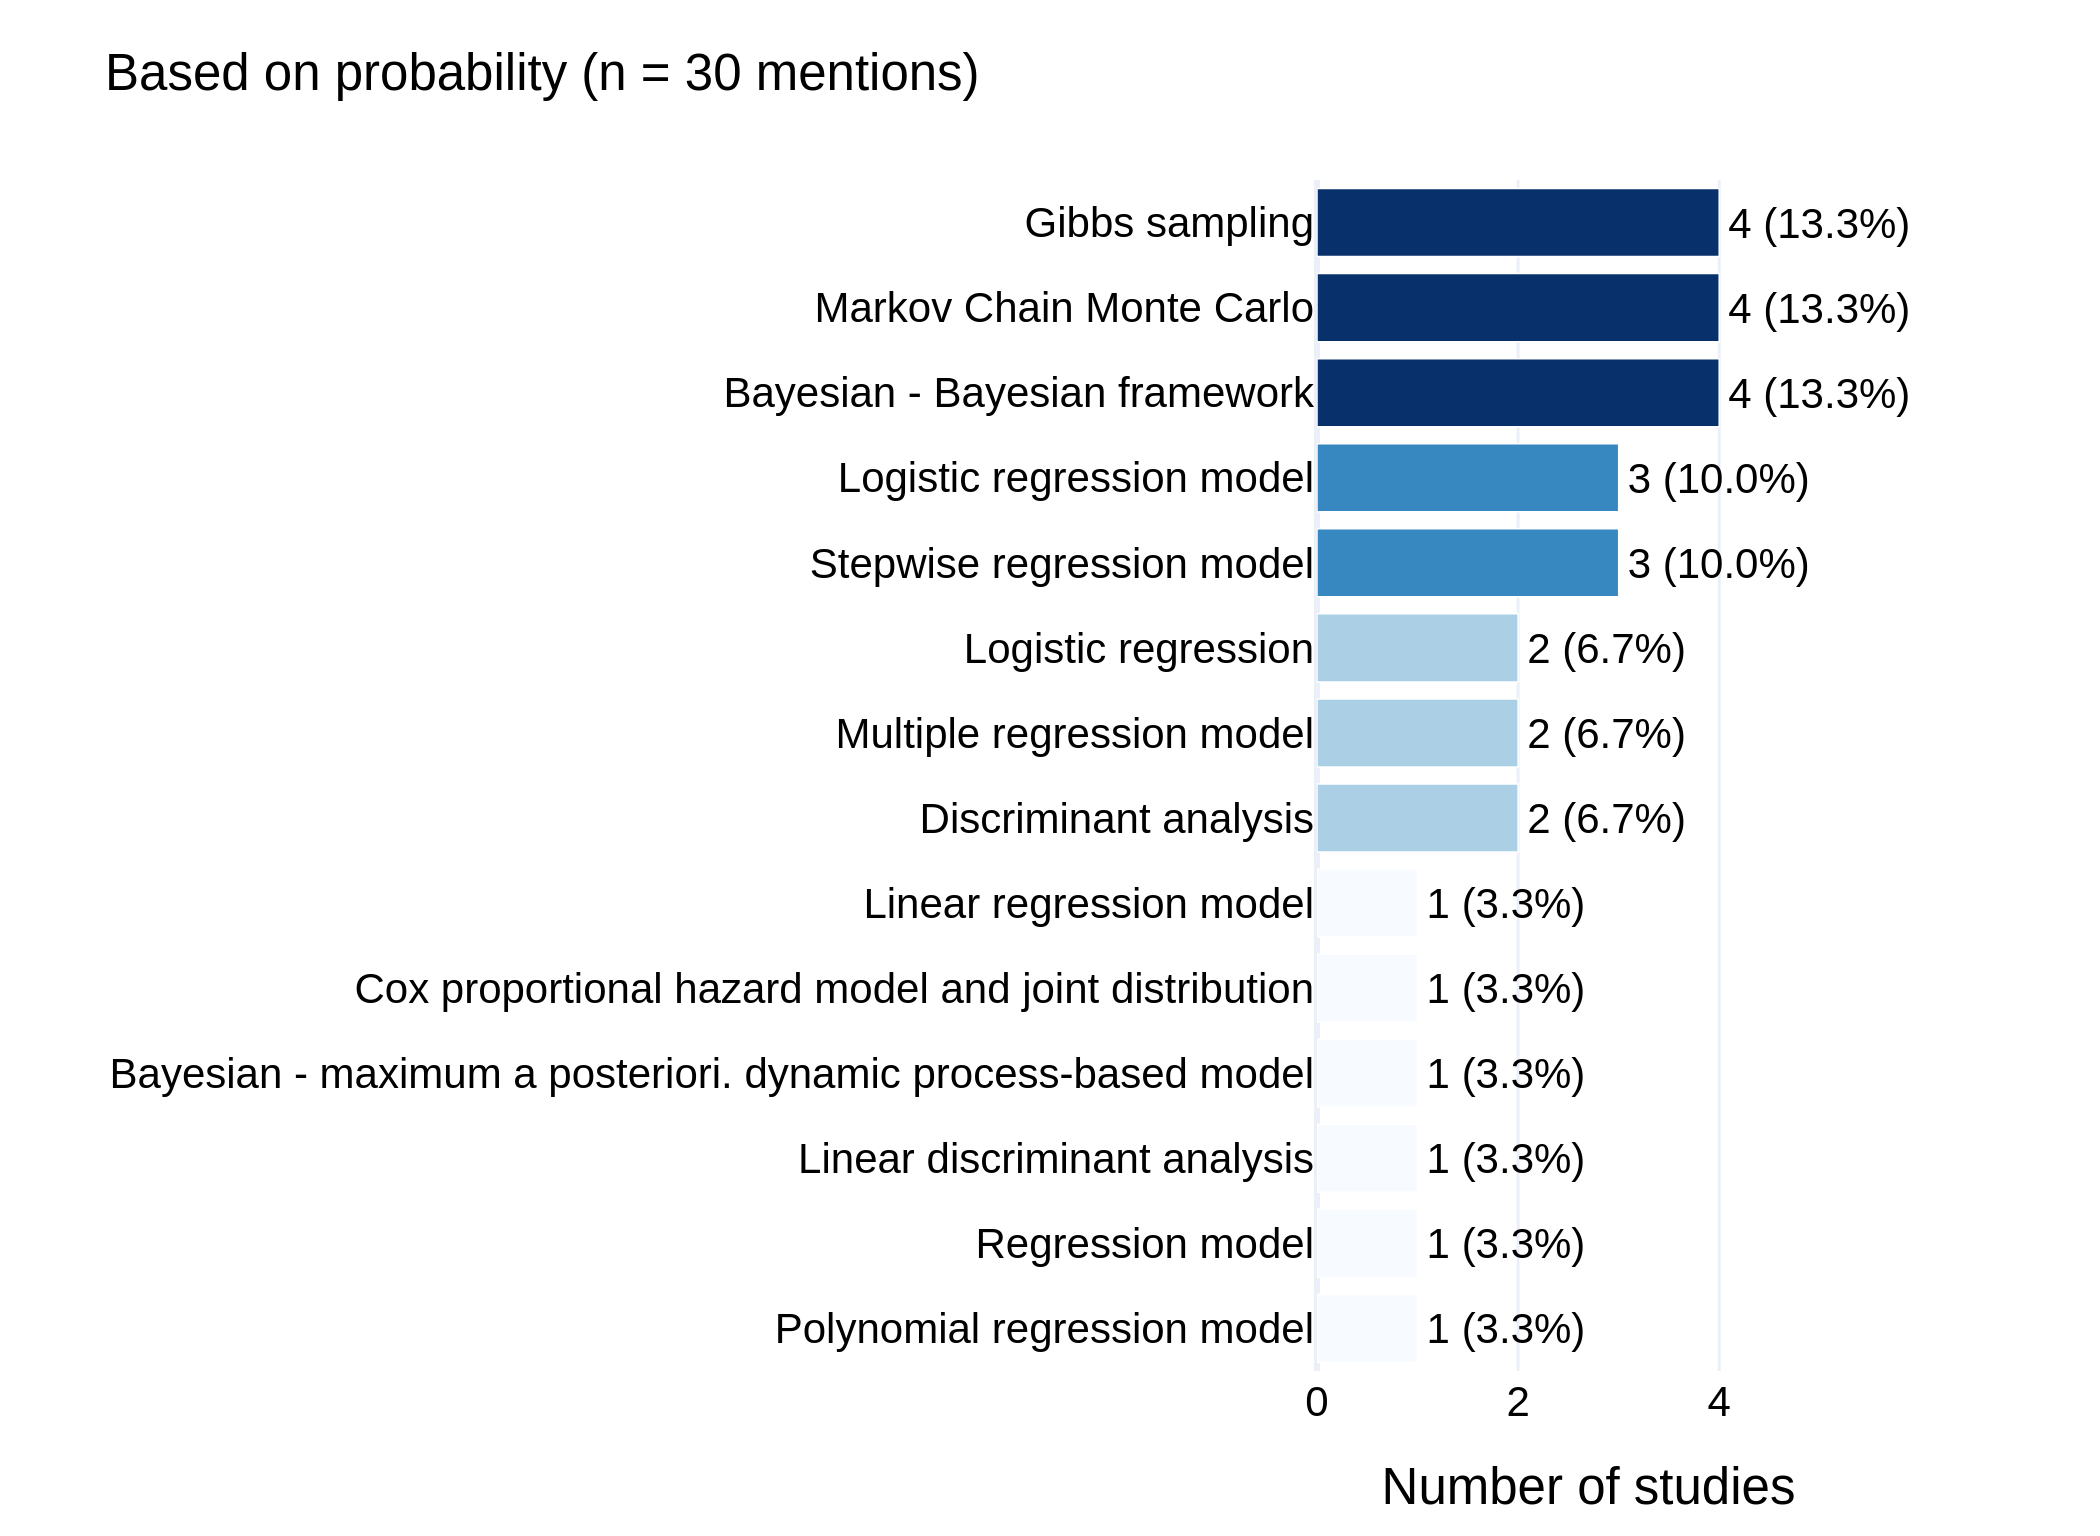

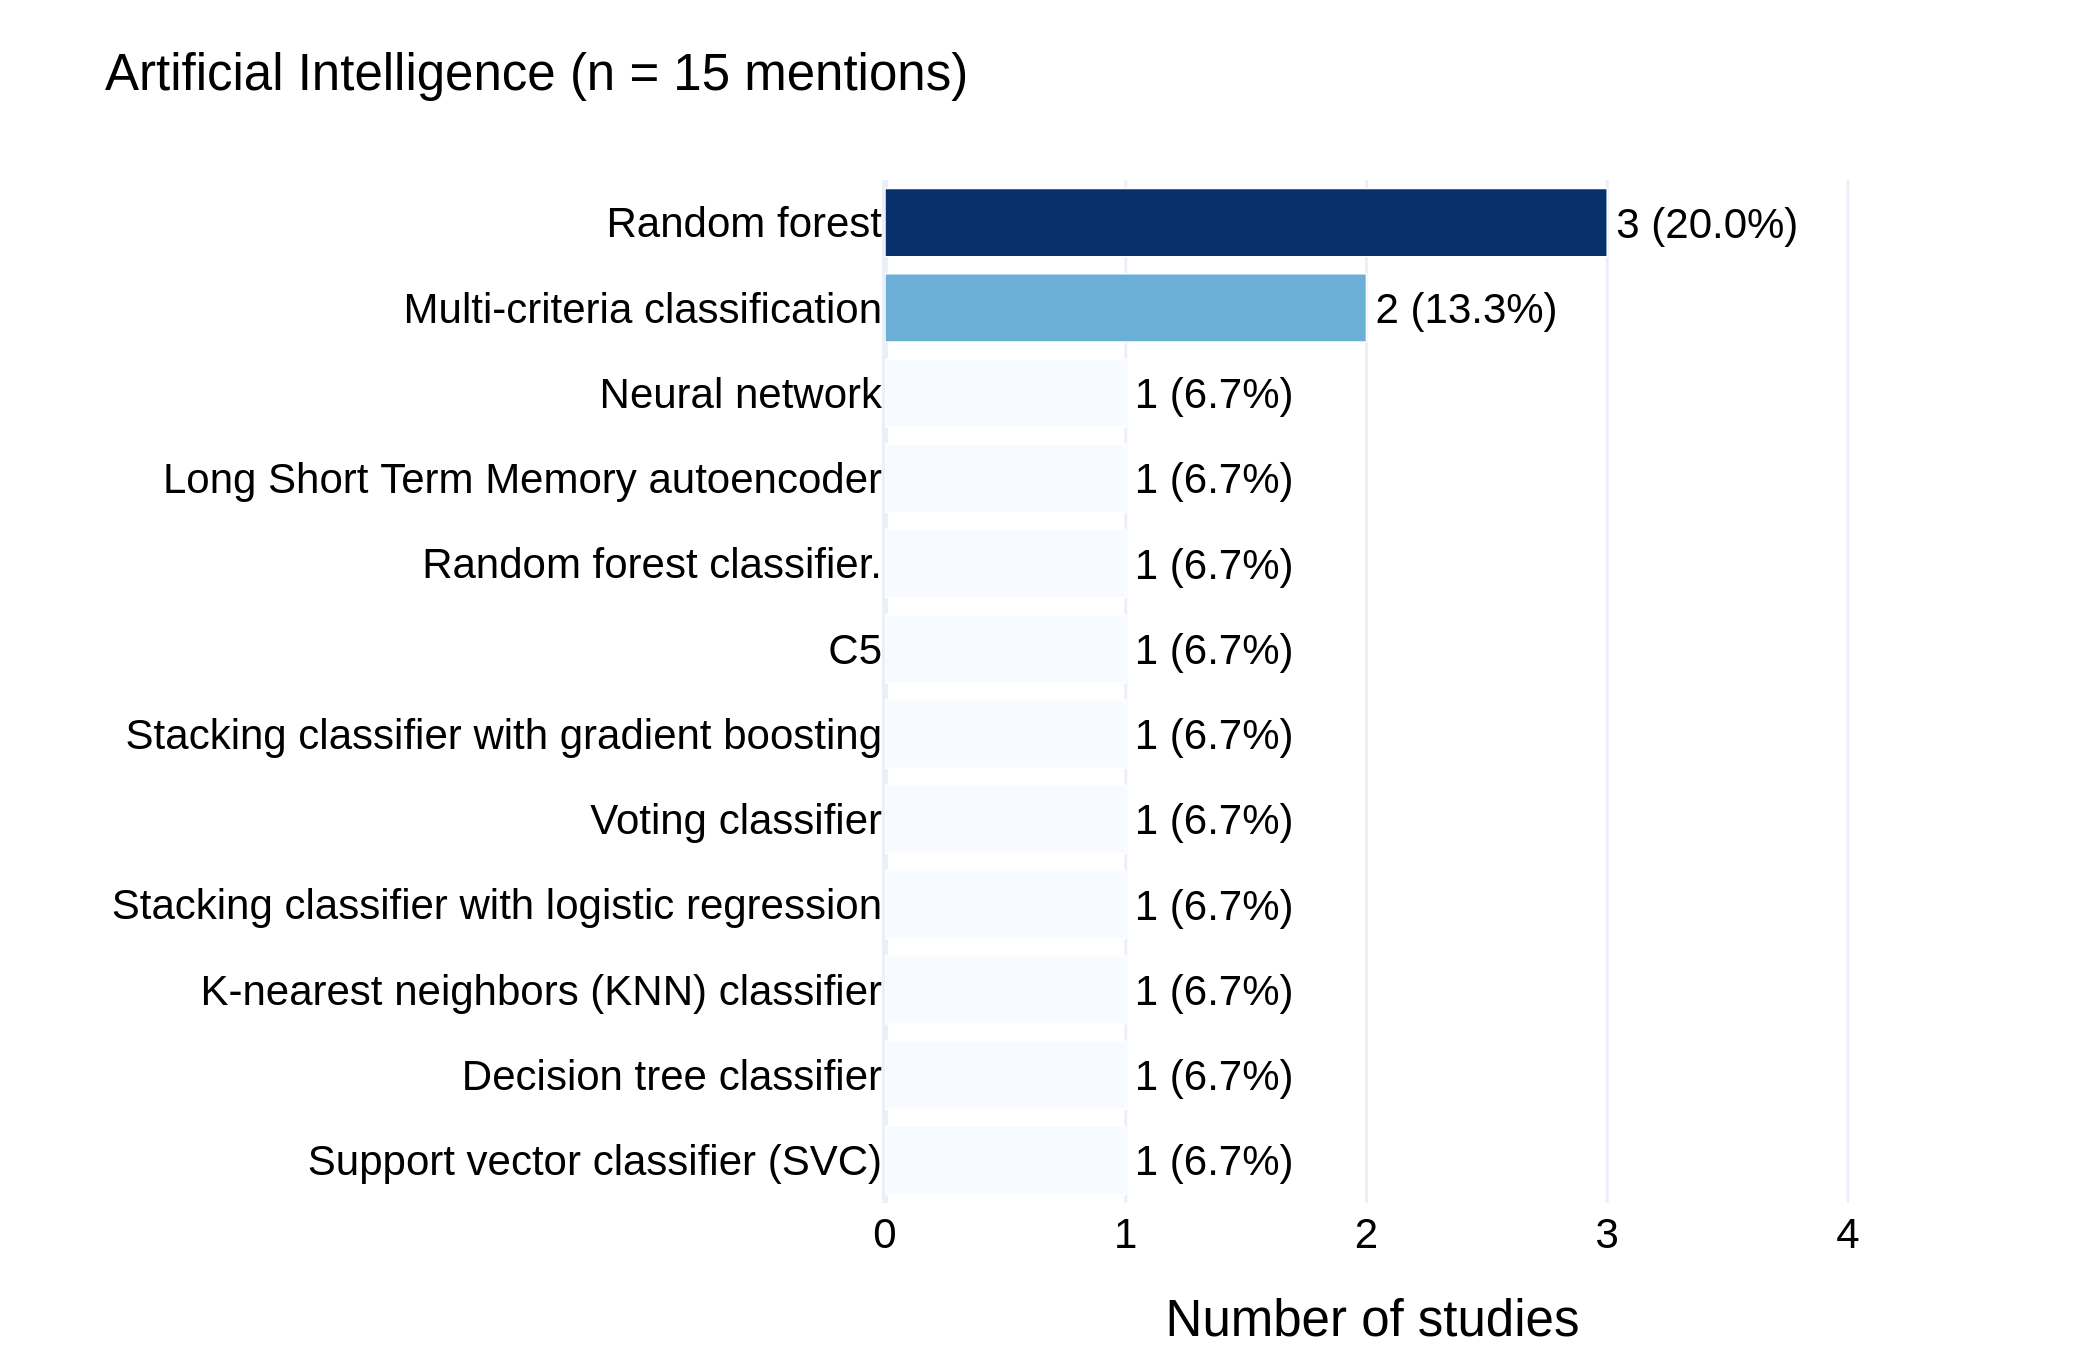

In [27]:
for g in ['Deterministic', 'Based on probability', 'Artificial Intelligence']:
    dfg = data[data['Group'] == g]
    if dfg.empty:
        continue
    fig = plot_model_frequency(dfg, g)

    img_bytes = fig.to_image(format="png", scale=3)
    display(Image(img_bytes))

In [18]:
METRIC_INFO = {
    'accuracy':       dict(label='Accuracy', unit='proportion (0-1)'),
    'r2':             dict(label='Coefficient of determination (R²)', unit='dimensionless'),
    'rmse':           dict(label='Root mean square error (RMSE)', unit='units of the modeled variable'),
    'standard_error': dict(label='Standard error', unit='units of the modeled variable'),
}

def plot_metric_distributions(df, group_name):
    df_numbers = df[list(METRIC_INFO.keys())].apply(lambda col: col.map(extraer_numeros))

    figs = []
    for col, info in METRIC_INFO.items():
        values = [v for sub in df_numbers[col] for v in sub]
        if not values:
            continue
        n = len(values)

        fig, ax = plt.subplots(figsize=(5.5, 5))
        bp = ax.boxplot(values, widths=0.35, patch_artist=True, showfliers=False)
        for box in bp['boxes']:
            box.set(facecolor='#a6cee3', alpha=0.6, edgecolor='black')
        for median in bp['medians']:
            median.set(color='black', linewidth=2)

        jitter_x = np.random.normal(1, 0.045, size=n)
        ax.scatter(jitter_x, values, alpha=0.6, color='#1f78b4', edgecolor='black',
                   linewidth=0.3, s=45, zorder=3)

        ax.set_xticks([])
        ax.set_title(f'{group_name}\n{info["label"]}', fontsize=15)
        ax.set_ylabel(info['unit'], fontsize=14)
        ax.tick_params(axis='y', labelsize=13)
        ax.text(0.5, -0.09, f'n = {n} reported values', transform=ax.transAxes,
                ha='center', fontsize=12, color='dimgray')
        ax.grid(axis='y', linestyle='--', alpha=0.35)
        plt.tight_layout()
        figs.append(fig)
    return figs

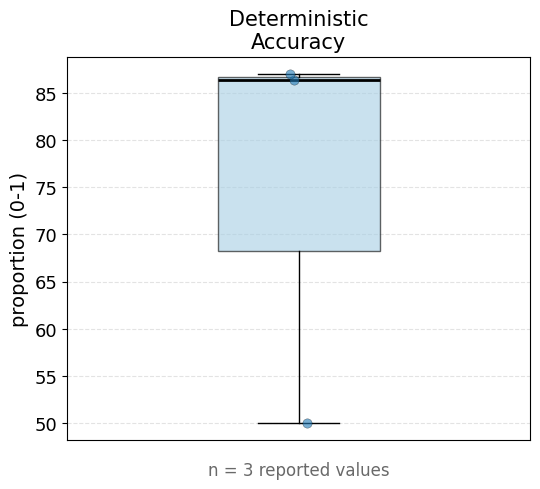

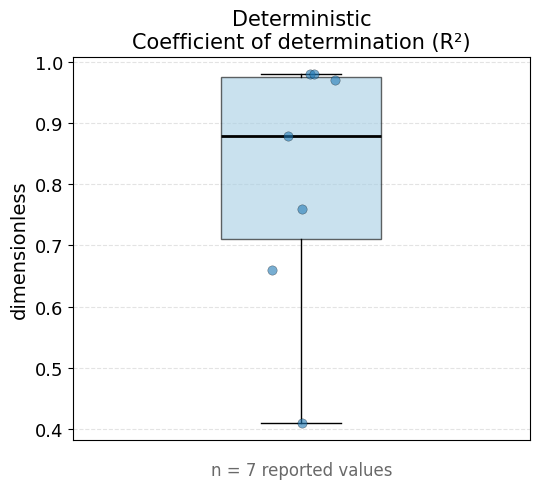

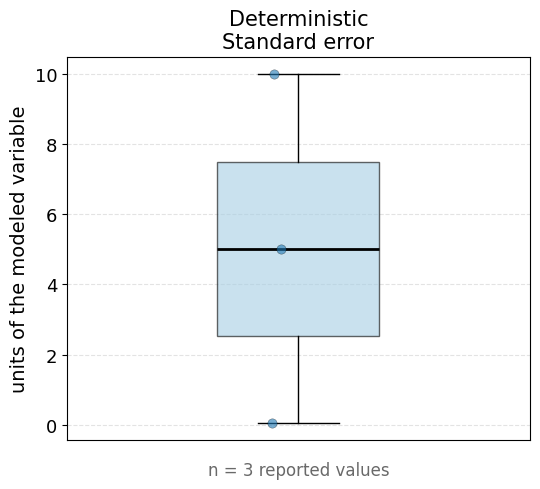

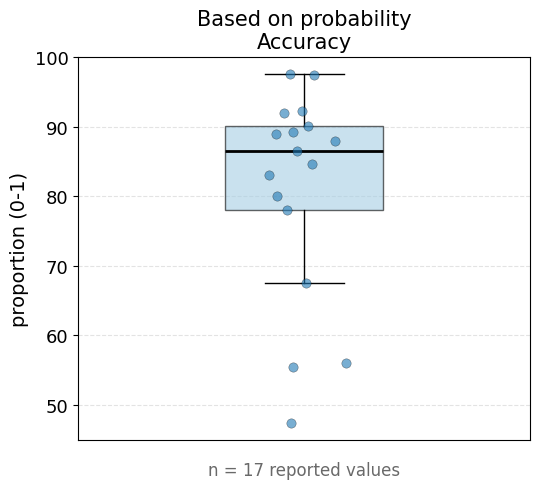

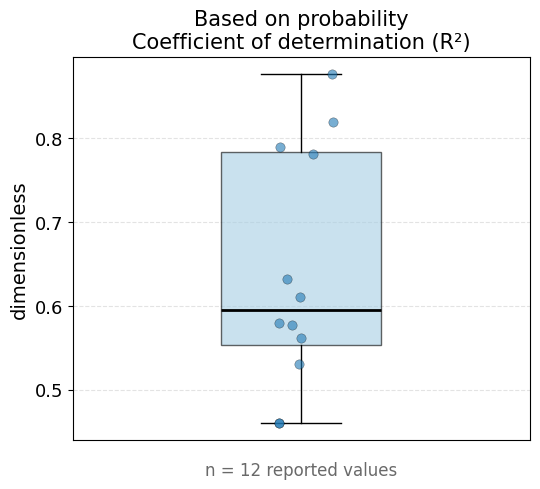

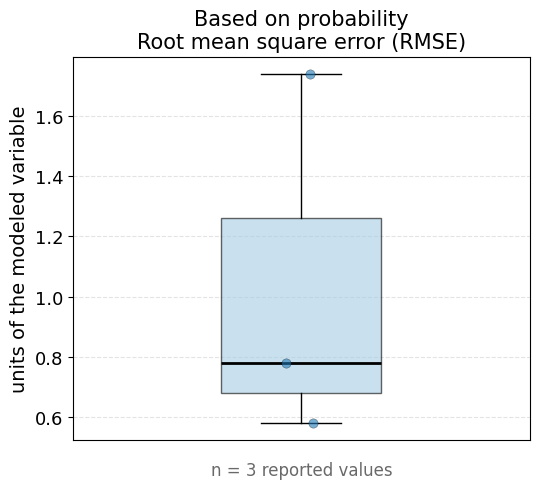

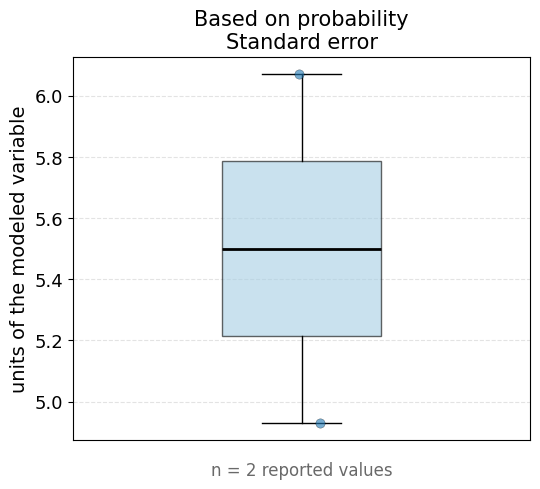

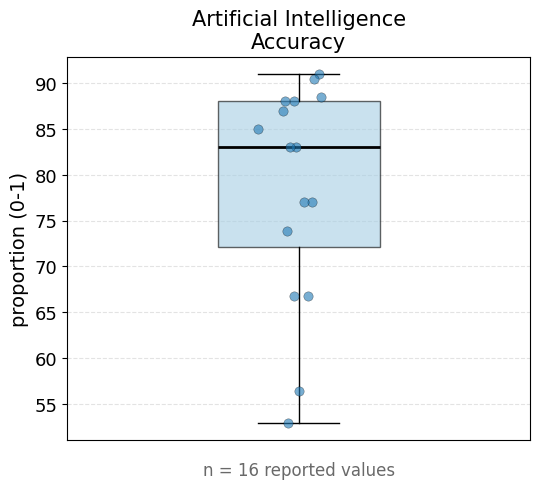

In [19]:
for g in ['Deterministic', 'Based on probability', 'Artificial Intelligence']:
    dfg = data[data['Group'] == g]
    if dfg.empty:
        continue
    figs = plot_metric_distributions(dfg, g)
    for fig in figs:
        plt.show()